# FFT e IFFT


In [4]:
import numpy as np
import matplotlib.pyplot as plt

## Fast Fourier Transform


In [2]:
def FFT(P):
    """
    Computes the Fast Fourier Transform of a polynomial P.
    Input: P is a list of coefficients of the polynomial, where P[i] is the coefficient of x^i.
    Output: A list of the values of the polynomial at the n-th roots of unity,
    """

    n = len(P)  # n is a power of 2
    if n == 1:
        return P
    w = np.exp(2 * np.pi * 1j / n)

    P_e, P_o = P[0::2], P[1::2]  # even and odd coefficients
    y_e, y_o = FFT(P_e), FFT(P_o)  # recursive calls

    y = [0] * n

    for j in range(n // 2):
        y[j] = y_e[j] + w**j * y_o[j]
        y[j + n // 2] = y_e[j] - w**j * y_o[j]

    return y

## Inverse Fast Fourier Transform


In [31]:
def IFFT(P):
    """
    Computes the Inverse Fast Fourier Transform of a polynomial P.
    Input: P is a list of values of the polynomial at the n-th roots of unity.
    Output: A list of coefficients of the polynomial, where P[i] is the coefficient of x^i.
    """

    def _IFFT(A):
        n = len(A)  # n is a power of 2
        if n == 1:
            return A
        w = np.exp(-2 * np.pi * 1j / n)

        A_e, A_o = A[0::2], A[1::2]  # even and odd coefficients
        y_e, y_o = _IFFT(A_e), _IFFT(A_o)  # recursive calls

        y = [0] * n

        for j in range(n // 2):
            y[j] = y_e[j] + w**j * y_o[j]
            y[j + n // 2] = y_e[j] - w**j * y_o[j]

        return y

    y_raw = _IFFT(P)
    N = len(P)
    return [y_i / N for y_i in y_raw]

256


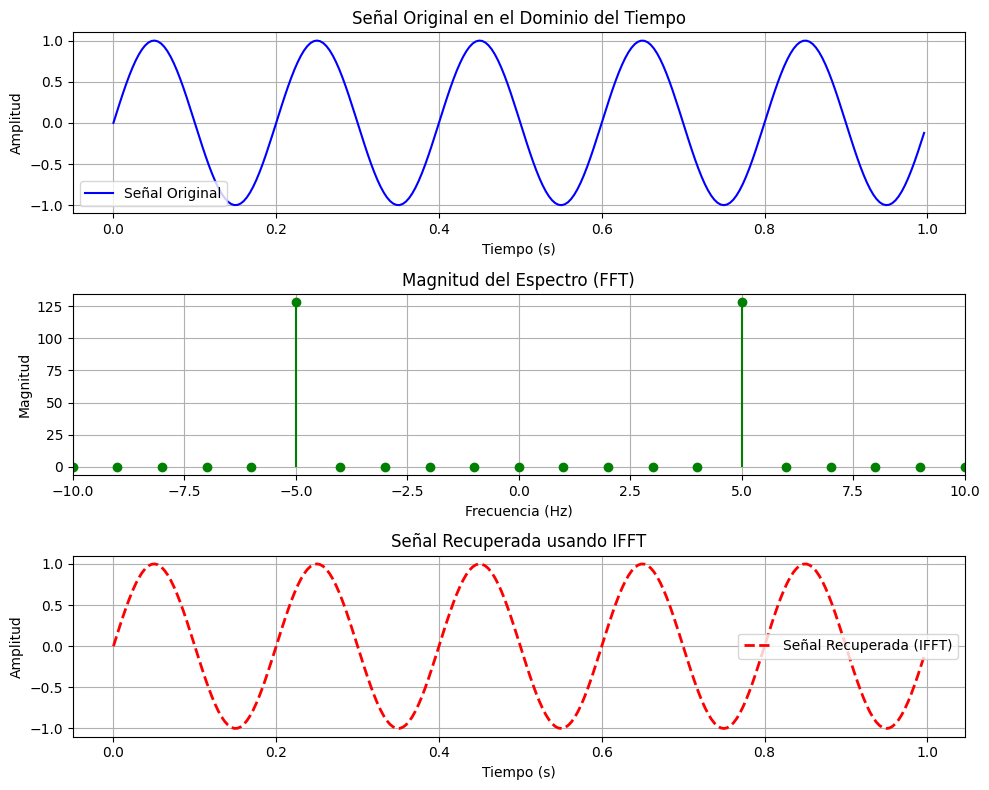

In [ ]:
N = 256
t = np.linspace(0, 1, N, endpoint=False)

P = np.sin(2 * np.pi * 5 * t)

fft_resultado = FFT(list(P))

ifft_resultado = IFFT(fft_resultado)

ifft_recuperada = np.real(ifft_resultado)
frecuencias = np.fft.fftfreq(N, d=1 / N)

plt.figure(figsize=(10, 8))

# Gráfico de la Señal Original
plt.subplot(3, 1, 1)
plt.plot(t, P, "b-", label="Señal Original")
plt.title("Señal Original en el Dominio del Tiempo")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)

# Gráfico de la Magnitud de la FFT
plt.subplot(3, 1, 2)
plt.stem(frecuencias, np.abs(fft_resultado), "g", markerfmt="go", basefmt=" ")
plt.title("Magnitud del Espectro (FFT)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(-10, 10)
plt.grid(True)

# Gráfico de la Señal Recuperada
plt.subplot(3, 1, 3)
plt.plot(t, ifft_recuperada, "r--", label="Señal Recuperada (IFFT)", linewidth=2)
plt.title("Señal Recuperada usando IFFT")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Coeficientes de A(x): [1, 2, 1, 0, 0, 0, 0, 0]
Coeficientes de B(x): [1, -2, 1, 0, 0, 0, 0, 0]
Coeficientes de C(x) obtenidos con IFFT: [np.float64(1.0), np.float64(0.0), np.float64(-2.0), np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


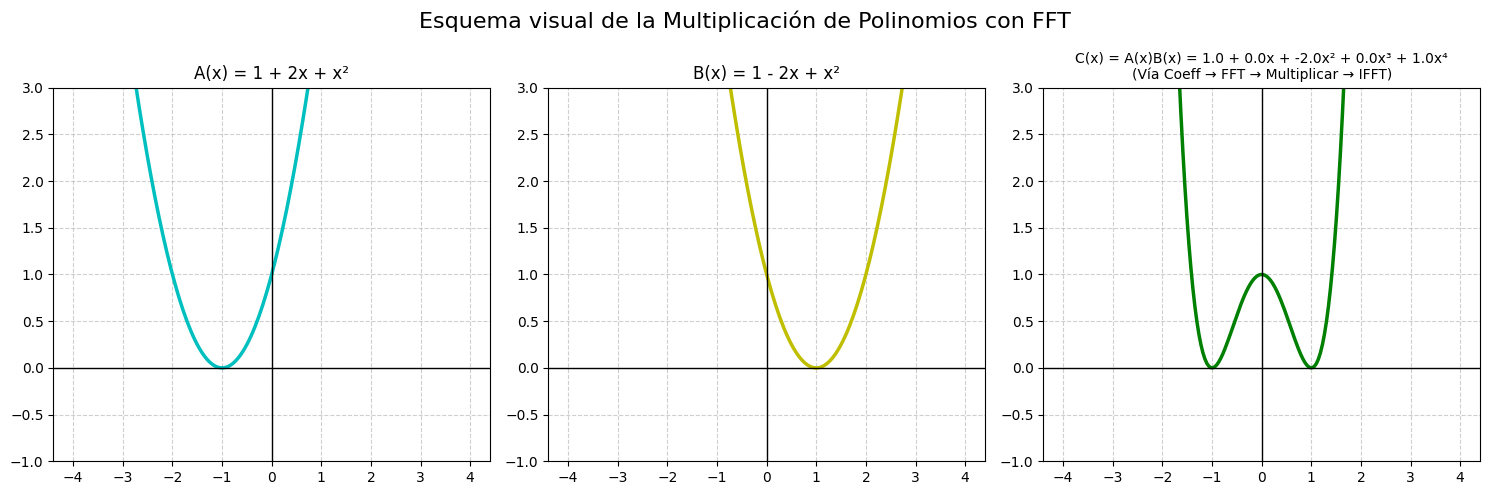

In [33]:
# Multiplicación de polinomios: A(x) * B(x) = C(x)
# A(x) = 1 + 2x + x^2
# B(x) = 1 - 2x + x^2
# Producto esperado C(x) = (1 + 2x + x^2)(1 - 2x + x^2) = 1 + 0x - 2x^2 + 0x^3 + x^4 = 1 -2x^2 + x^4

# 1. Rellenar los vectores de coeficientes a una potencia de 2 (N=8 porque grado máximo de C es 4)
N = 8
A_coef = [1, 2, 1, 0, 0, 0, 0, 0]
B_coef = [1, -2, 1, 0, 0, 0, 0, 0]

# 2. Convertir de Coeficientes a Valores evaluando en raíces de la unidad usando FFT
A_val = FFT(A_coef)
B_val = FFT(B_coef)

# 3. Multiplicar punto a punto en el dominio de los valores
C_val = [a * b for a, b in zip(A_val, B_val)]

# 4. Convertir los Valores nuevamente a Coeficientes interpolando con IFFT
C_coef_raw = IFFT(C_val)

C_coef = np.round(np.real(C_coef_raw), 5)

print("Coeficientes de A(x):", A_coef)
print("Coeficientes de B(x):", B_coef)
print("Coeficientes de C(x) obtenidos con IFFT:", list(C_coef))

x_vals = np.linspace(-4.0, 4.0, 200)


def evaluar_polinomio(coefs, x):
    return sum(c * x**i for i, c in enumerate(coefs))


fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Gráfico de A(x)
axs[0].plot(x_vals, evaluar_polinomio(A_coef, x_vals), "c", linewidth=2.5)
axs[0].set_title("A(x) = 1 + 2x + x²")
axs[0].set_ylim(-1, 3)  # Acercamos el eje Y
axs[0].axhline(0, color="black", linewidth=1)
axs[0].axvline(0, color="black", linewidth=1)
axs[0].grid(True, linestyle="--", alpha=0.6)

# Gráfico de B(x)
axs[1].plot(x_vals, evaluar_polinomio(B_coef, x_vals), "y", linewidth=2.5)
axs[1].set_title("B(x) = 1 - 2x + x²")
axs[1].set_ylim(-1, 3)  # Acercamos el eje Y
axs[1].axhline(0, color="black", linewidth=1)
axs[1].axvline(0, color="black", linewidth=1)
axs[1].grid(True, linestyle="--", alpha=0.6)

# Gráfico de C(x) resultante
axs[2].plot(x_vals, evaluar_polinomio(C_coef, x_vals), "g", linewidth=2.5)
axs[2].set_title(
    f"C(x) = A(x)B(x) = {C_coef[0]} + {C_coef[1]}x + {C_coef[2]}x² + {C_coef[3]}x³ + {C_coef[4]}x⁴\n(Vía Coeff → FFT → Multiplicar → IFFT)",
    fontsize=10,
)
axs[2].set_ylim(-1, 3)  # Acercamos el eje Y para ver los detalles cerca del origen
axs[2].axhline(0, color="black", linewidth=1)
axs[2].axvline(0, color="black", linewidth=1)
axs[2].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Esquema visual de la Multiplicación de Polinomios con FFT", fontsize=16)
plt.tight_layout()
plt.show()